In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Lecturas bajas

In [3]:
df_raw = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains('Norm')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df_raw = df_raw.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T


Consideramos variables con lectuas bajas aquellas que tengan una frecuencia mayor del 50% con lecturas de menor de un threshold:

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

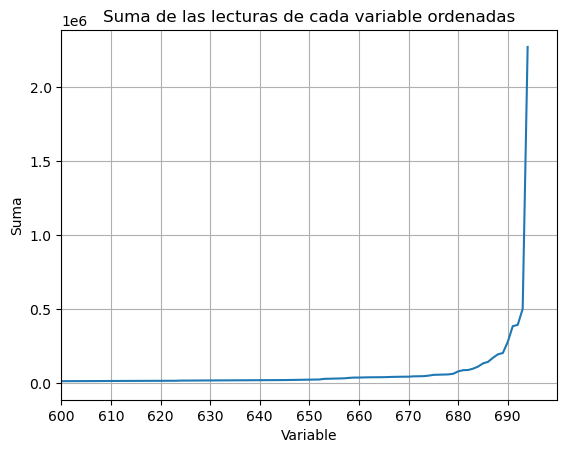

In [4]:

# Primer gráfico: Suma
plt.xticks(np.arange(600, 700, 10))
plt.plot(df_raw.sum().sort_values().to_list())
plt.xlim(600, 700)
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

In [5]:
x_objetivo = 600

suma_lecturas = df_raw.sum().sort_values()
suma_lecturas_list = suma_lecturas.to_list()
indice_mas_cercano = np.abs(suma_lecturas.reset_index(drop = True).index - x_objetivo).argmin()
valor_y_correspondiente = suma_lecturas.iloc[indice_mas_cercano]

print(f"El valor de y correspondiente a x={x_objetivo} es: {valor_y_correspondiente}")


El valor de y correspondiente a x=600 es: 12331


In [6]:
suma_min = valor_y_correspondiente
filtered = df_raw.sum().sort_values()
cols_interes = filtered[filtered>suma_min].index.to_list()
df_raw_lecAltas1 = df_raw[cols_interes]
len(df_raw_lecAltas1.columns)

94

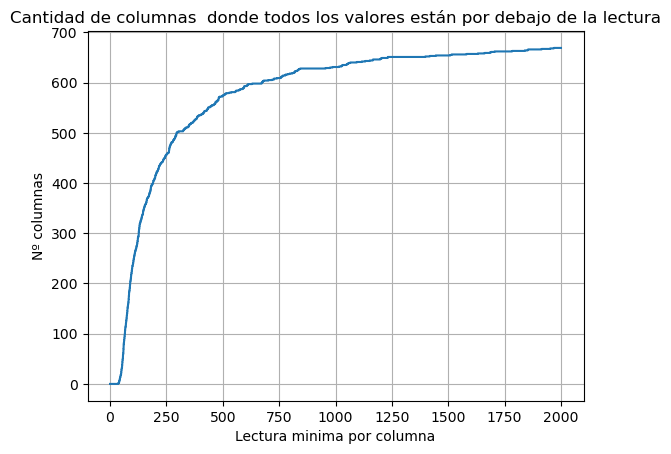

In [7]:
lista_mediaCercACero = []
lecturas_mins = np.arange(0,2000,0.1)
for lectMin in lecturas_mins:
    #for frec in np.arange(0,1,0.1):
    mediaCercACero = (df_raw < lectMin).sum() #vemos cuántos valores de cada columna están por debajo de ese umbral
    mediaCercACero = mediaCercACero[mediaCercACero == len(df_raw)] #Filtramos las columnas en donde todos los valores están por debajo de ese umbral
    lista_mediaCercACero.append(len(mediaCercACero))
#plt.xticks(np.arange(0,20,1))
plt.plot(lecturas_mins,lista_mediaCercACero)
plt.xlabel('Lectura minima por columna')
plt.ylabel('Nº columnas')
plt.title('Cantidad de columnas  donde todos los valores están por debajo de la lectura') 
plt.grid(True)
plt.show()




In [8]:
ncol = 600
indice_mas_cercano = np.abs(np.array(lista_mediaCercACero) - ncol).argmin()
lectura_correspondiente = lecturas_mins[indice_mas_cercano] 
print(f"El valor de lectura correspondiente a y={ncol} es aproximadamente: {lectura_correspondiente}")

El valor de lectura correspondiente a y=600 es aproximadamente: 673.1


In [9]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

95

In [10]:
colsLectAlta = list(set(df_raw_lecAltas1.columns.to_list() + df_raw_lecAltas2.columns.to_list()))
len(colsLectAlta)
print(len(df_raw.columns),'->',len(colsLectAlta))

695 -> 106


### Variaciones bajas

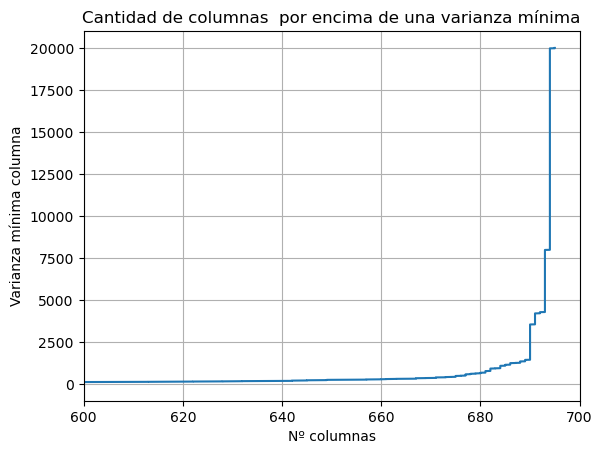

In [11]:
lista_vars = []
vars_mins = range(0,20000)
df_vars = df_raw.std()
for varMin in vars_mins:
    nVarsStd = len(df_vars[df_vars<varMin])
    lista_vars.append(nVarsStd)
#plt.xticks(np.arange(0,20,1))
plt.plot(lista_vars, vars_mins)
plt.xlim(600, 700)
plt.xlabel('Nº columnas')
plt.ylabel('Varianza mínima columna')
plt.title('Cantidad de columnas  por encima de una varianza mínima') 
plt.grid(True)
plt.show()

In [12]:
lista_vars_array = np.array(lista_vars)
vars_mins_array = np.array(vars_mins)
x_objetivo = 660
indice_mas_cercano = np.abs(lista_vars_array - x_objetivo).argmin()
varianza_minima_correspondiente = vars_mins_array[indice_mas_cercano]

print(f"La varianza mínima correspondiente a x={x_objetivo} columnas es: {varianza_minima_correspondiente}")

La varianza mínima correspondiente a x=660 columnas es: 268


In [13]:
colsVarAlta = df_vars[df_vars>varianza_minima_correspondiente].index.to_list()
print(len(df_raw.columns),'->',len(colsVarAlta))


695 -> 35


### Tests

Se procede a hacer un test para cada variable para determinar si existen diferencias significativas entre el grupo de Tratamiento y Control. Esto nos permitirá saber si cada variable es estadíticamente diferente o no. Las que no son diferentes podemos procederlas a eliminarlas ya que el objetivo de este análisis es determinar las diferencias entre ambos grupos

In [14]:
colsSeleccion = list(set(colsLectAlta + colsVarAlta))
len(colsSeleccion)

106

In [15]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [16]:
df_norm = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df_norm = df_norm.loc[:, ~df_norm.columns.str.contains('Raw')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df_norm = df_norm.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T
df_norm_seleccion = df_norm[colsSeleccion]

In [17]:
####Dividmos el data set en dos: Uno de tratamiento y otro de control

df1_ct = df_norm_seleccion.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

In [18]:
variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

In [19]:
print(len(variables),'→',len(variablesIncluir))

106 → 13


### Correlaciones

In [20]:
import seaborn as sns

In [21]:
df1 = df_norm[variablesIncluir]

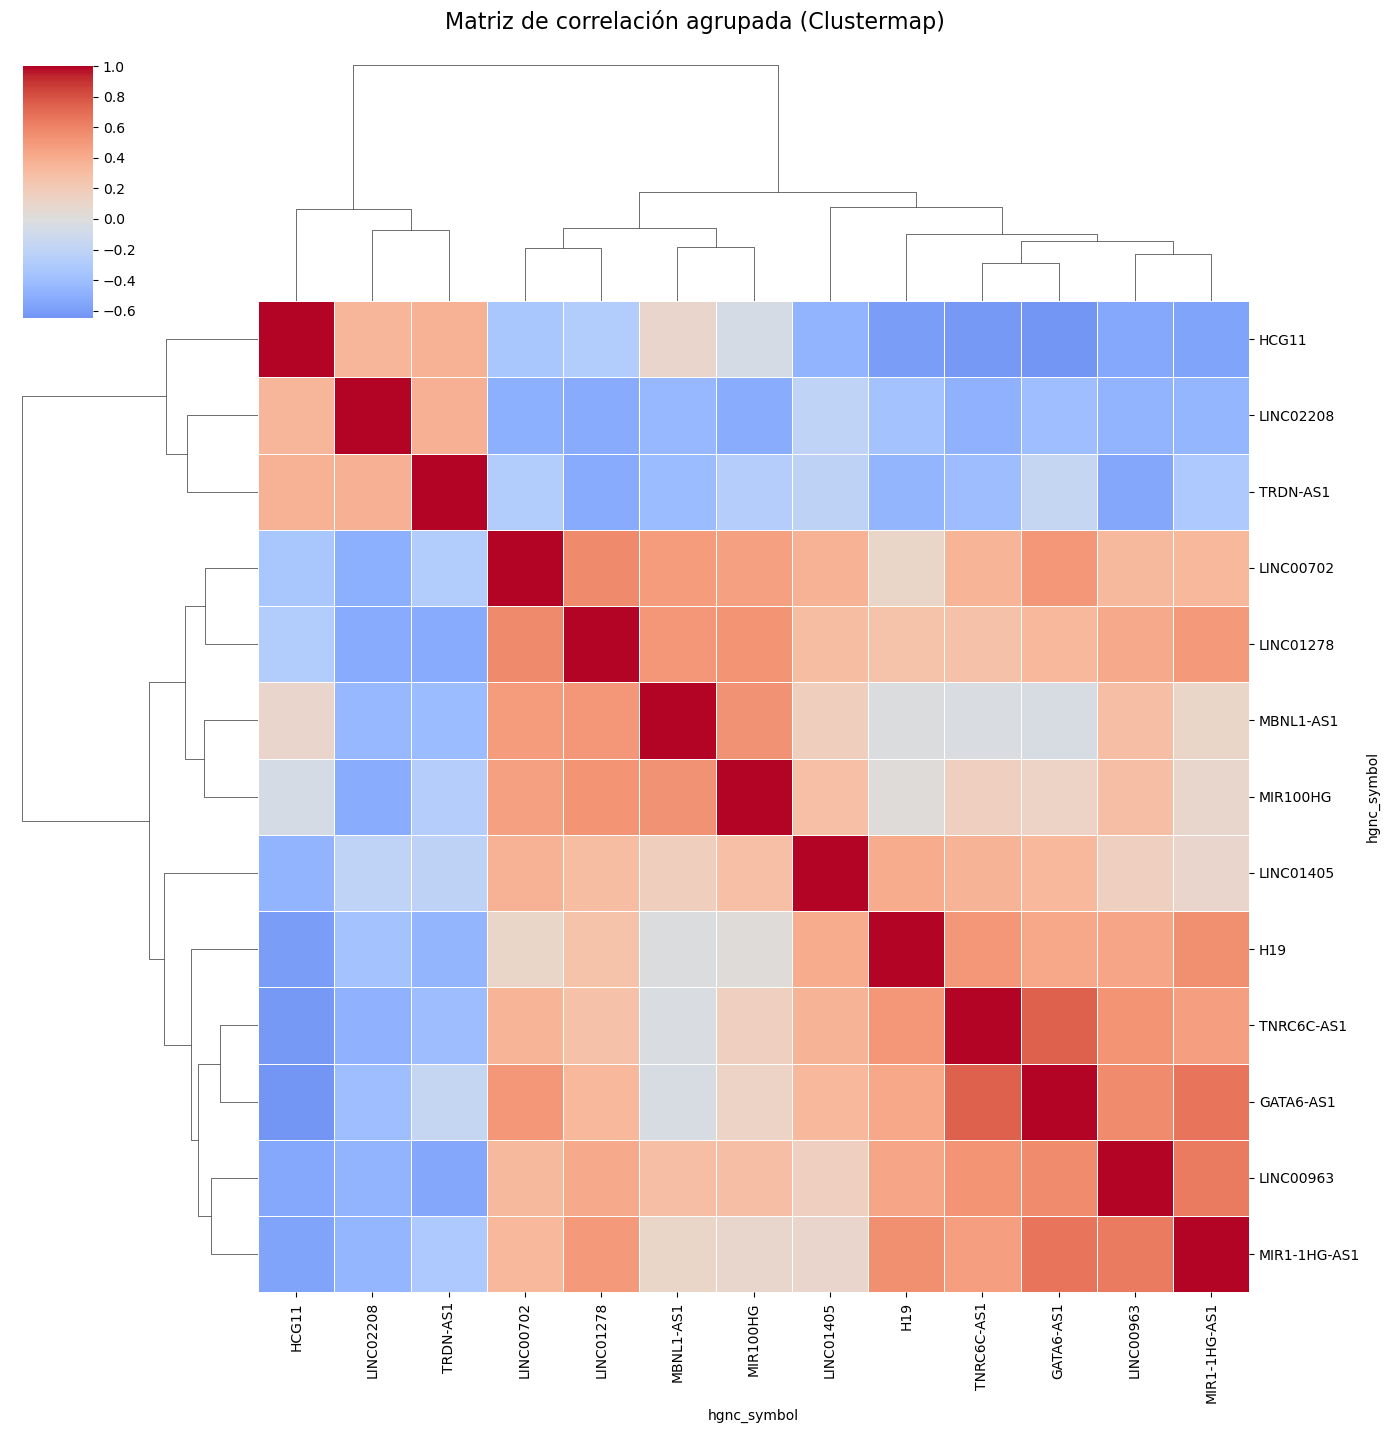

In [22]:
corr = df1.corr(method='spearman')

# Dibuja el clustermap
sns.clustermap(corr,
               cmap='coolwarm',
               center=0,
               figsize=(14, 14),
               linewidths=0.5,
               annot=False,
               cbar_kws={"shrink": 0.7})

plt.suptitle('Matriz de correlación agrupada (Clustermap)', y=1.02, fontsize=16)
plt.show()

Podemos usar 0.75 como threshold

In [23]:
df_list = []
threshold = 0.7
correlaciones_vars = df1.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df1.columns)        
df1 = df1.drop(columns=columns_to_drop)   
print(nvarsAntes,'variables →',len(df1.columns),'variables')

13 variables → 12 variables


### Random Forest

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score,cross_val_predict, train_test_split
from sklearn.metrics  import roc_curve, auc, accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [25]:
scaler = StandardScaler()
df_scaled  = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled = df_scaled.set_index(df1.index)
df_scaled2 = df_scaled.copy()
df_scaled2 = df_scaled2.reset_index()
df_scaled2['Grupo'] = np.where(df_scaled2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled2['index'].str.contains('C'), 'Control', 'Otro'))
df_scaled2 = df_scaled2.set_index('index')
df_scaled2 = pd.get_dummies(df_scaled2, columns=['Grupo'], drop_first=True)
df_scaled2['Grupo_Tratamiento'] = df_scaled2['Grupo_Tratamiento'].astype(int)

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-pa

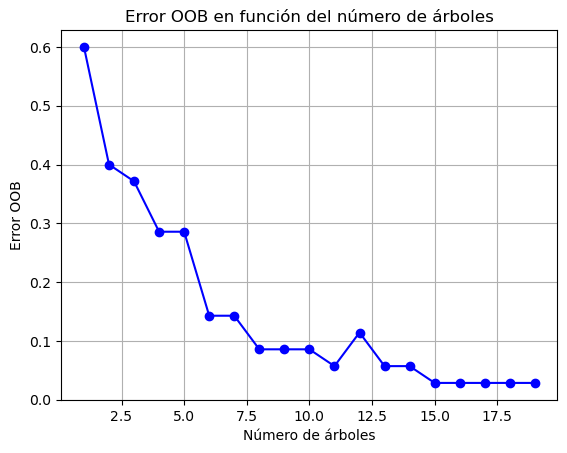

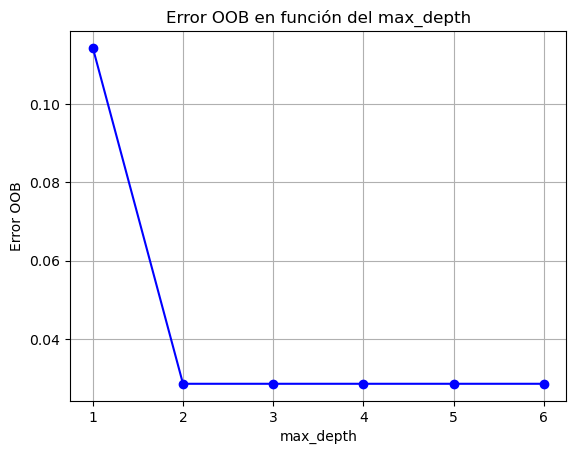

In [ ]:
X = df_scaled2.drop(columns=["Grupo_Tratamiento"])  
y = df_scaled2["Grupo_Tratamiento"]
estimadores = range(1, 20, 1)
oob_errors = []

for n_estimators in estimadores:  
    rf = RandomForestClassifier(n_estimators=n_estimators, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(estimadores, oob_errors, marker='o', color='b')
plt.xlabel('Número de árboles')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del número de árboles')
plt.grid(True)
plt.show()

oob_errors = []
profundidades = range(1, 7)
for max_depth in profundidades:  
    rf = RandomForestClassifier(n_estimators=200, max_depth=max_depth, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(profundidades, oob_errors, marker='o', color='b')
plt.xlabel('max_depth')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del max_depth')
plt.grid(True)
plt.show()

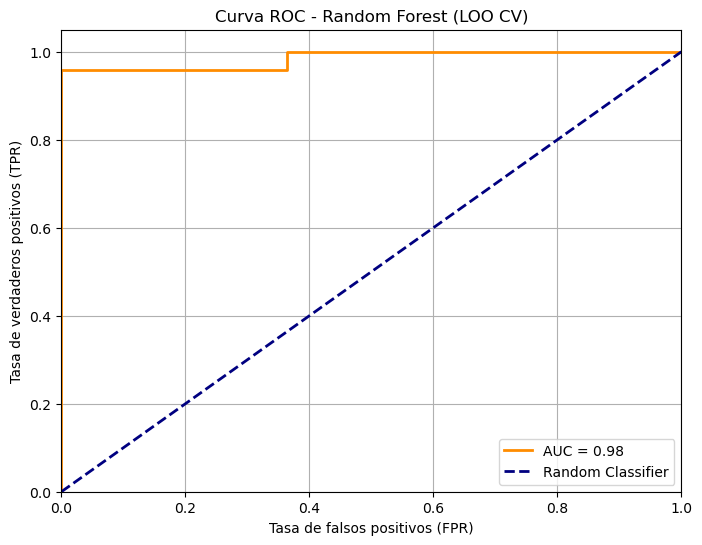

Precisión media en entrenamiento: 1.0
Precisión media en test: 0.9428571428571428
AUC de la curva ROC: 0.9848484848484849
Tasa de verdaderos negativos (TNR - especificidad): 0.9090909090909091
Tasa de falsos negativos (FNR): 0.041666666666666664
Tasa de verdaderos  positivos (TPR): 0.9583333333333334
Tasa de falsos positivos (FPR): 0.09090909090909091


In [94]:
n_estimators = 11
max_depth = 2

X = df_scaled2.drop(columns=["Grupo_Tratamiento"])  
y = df_scaled2["Grupo_Tratamiento"]

# Inicializar modelo
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)

# Inicializar LOO
loo = LeaveOneOut()

# Acumuladores
accuracies_train = []
accuracies_test = []
y_true = []
y_pred_proba = []
y_pred_class = []

# Loop LOO
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)

    # Predicciones
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    # Guardar resultados
    accuracies_train.append(accuracy_score(y_train, y_train_pred))
    accuracies_test.append(accuracy_score(y_test, y_test_pred))
    y_true.append(y_test.values[0])
    y_pred_proba.append(y_test_proba[0])
    y_pred_class.append(y_test_pred[0])

# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_true, y_pred_class)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest (LOO CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
print("Precisión media en entrenamiento:", np.mean(accuracies_train))
print("Precisión media en test:", np.mean(accuracies_test))
print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)

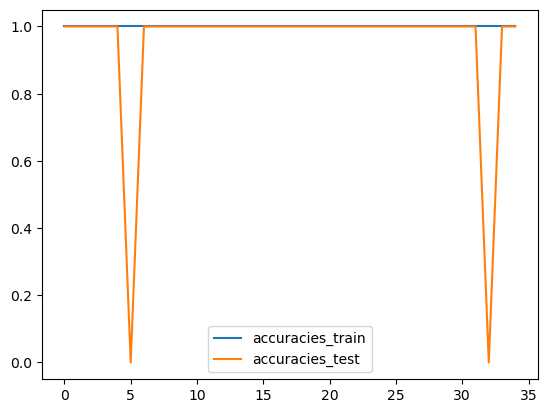

In [95]:
plt.plot(accuracies_train,label = 'accuracies_train')
plt.plot(accuracies_test,label = 'accuracies_test')
plt.legend()
plt.show()

In [101]:
indices_cero = [i for i, valor in enumerate(accuracies_test) if valor == 0]
indices_cero

[5, 32]

In [104]:
X_test_mal = []
y_test_mal = []
for train_index, test_index in loo.split(X):
    if test_index == 5 or test_index == 32:
        X_test_mal.append(X.iloc[test_index])
        y_test_mal.append(y.iloc[test_index])

In [116]:
print(y_test_mal)
print(X_test_mal)

[index
Norm_A445    1
Name: Grupo_Tratamiento, dtype: int64, index
Norm_C104    0
Name: Grupo_Tratamiento, dtype: int64]
[           TNRC6C-AS1  MBNL1-AS1  LINC02208    HCG11  MIR100HG       H19  \
index                                                                      
Norm_A445   -0.906433   0.313933   0.506713 -0.06293 -0.118696 -0.116594   

           LINC00702  LINC00963  MIR1-1HG-AS1  LINC01278  TRDN-AS1  LINC01405  
index                                                                          
Norm_A445  -0.877014  -0.469329     -1.248398   0.660954 -1.166916   0.357452  ,            TNRC6C-AS1  MBNL1-AS1  LINC02208     HCG11  MIR100HG       H19  \
index                                                                       
Norm_C104    0.109216  -0.907422   0.104539  0.527646 -0.606462 -0.702023   

           LINC00702  LINC00963  MIR1-1HG-AS1  LINC01278  TRDN-AS1  LINC01405  
index                                                                          
Norm_C104   -0.7

leaf1out 
cross-validation

### Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, accuracy_score
from tqdm import tqdm
from sklearn.utils import resample

In [ ]:
df2 = df[mostImpFeaturesTree['Feature'].to_list()]
df2 = df2.reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

In [ ]:
# Inicializar lista para guardar los resultados
resultados = []

# Número de iteraciones del bootstrap
n_iter = 5000
random_state = 42  
np.random.seed(random_state)

X_total = df2.drop(columns='Grupo_Tratamiento')
y_total = df2['Grupo_Tratamiento']
variables_totales = X_total.columns.tolist()

for i in tqdm(range(n_iter)):
    # Selección aleatoria de variables
    n_vars = np.random.randint(5, len(variables_totales) + 1)
    vars_seleccionadas = np.random.choice(variables_totales, size=n_vars, replace=False)

    # Subset de variables seleccionadas
    X = X_total[vars_seleccionadas]
    y = y_total

    # Separar por clase
    X_0 = X[y == 0]
    X_1 = X[y == 1]
    y_0 = y[y == 0]
    y_1 = y[y == 1]

    # Balancear (tomar el mínimo de ambas clases para igualar)
    n_samples = min(len(X_0), len(X_1))

    # Bootstrap balanceado por clase
    X_0_boot, y_0_boot = resample(X_0, y_0, replace=True, n_samples=n_samples, random_state=None)
    X_1_boot, y_1_boot = resample(X_1, y_1, replace=True, n_samples=n_samples, random_state=None)

    # Concatenar clases balanceadas
    X_boot = pd.concat([X_0_boot, X_1_boot])
    y_boot = pd.concat([y_0_boot, y_1_boot])

    # Out-of-bag samples: eliminar los índices que fueron usados
    mask = ~X.index.isin(X_boot.index)
    X_oob = X.loc[mask]
    y_oob = y.loc[mask]

    # Escalar
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_oob_scaled = scaler.transform(X_oob) if not X_oob.empty else None

    # Hiperparámetro aleatorio
    c_value = 10 ** np.random.uniform(-2, 2)

    # Entrenar modelo
    modelo = LogisticRegression(penalty='l1', solver='liblinear', C=c_value, max_iter=1000)
    modelo.fit(X_boot_scaled, y_boot)

    # Evaluar
    if X_oob_scaled is not None and len(y_oob) > 0:
        y_pred_oob = modelo.predict(X_oob_scaled)
        y_pred_boot = modelo.predict(X_boot_scaled)
        r2 = r2_score(y_oob, y_pred_oob)
        acc_oob = accuracy_score(y_oob, y_pred_oob)
        acc_boot = accuracy_score(y_boot, y_pred_boot)
    else:
        r2 = np.nan
        acc_oob = np.nan
        acc_boot = accuracy_score(y_boot, modelo.predict(X_boot_scaled))

    # Guardar resultados
    for var, coef in zip(vars_seleccionadas, modelo.coef_[0]):
        resultados.append({
            'Iteración': i,
            'Variable': var,
            'Coeficiente': coef,
            'C': c_value,
            'R2': r2,
            'Accuracy_Test': acc_oob,
            'Accuracy_Train': acc_boot
        })

# Convertir a DataFrame final
df_resultados = pd.DataFrame(resultados)

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:48<00:00, 103.15it/s]


In [ ]:
#df_resultados = df_resultados[df_resultados['Coeficiente'] != 0]
df_resultados_bootstrpaLogit = df_resultados.groupby('Variable').agg(
    Conteo=('Variable', 'count'),
    Promedio_Coeficiente=('Coeficiente', 'mean'),
    Promedio_Train_accuracy=('Accuracy_Train','mean'),
    Promedio_Test_accuracy=('Accuracy_Test','mean')
).reset_index()



# Ordenar por porcentaje y promedio de importancia

df_resultados_bootstrpaLogit['Importancia (abs)'] = np.abs(df_resultados_bootstrpaLogit['Promedio_Coeficiente'])
df_resultados_bootstrpaLogit = df_resultados_bootstrpaLogit.sort_values(by=['Importancia (abs)'], ascending=False).drop(columns='Importancia (abs)').reset_index(drop=True)
df_resultados_bootstrpaLogit

,Variable,Conteo,Promedio_Coeficiente,Promedio_Train_accuracy,Promedio_Test_accuracy
0,ARRDC3-AS1,3077,0.729859,0.870018,0.735668
1,SNHG19,3083,-0.604095,0.868664,0.732713
2,LINC02208,3058,-0.544855,0.865435,0.728325
3,LINC00964,3076,-0.532932,0.869695,0.734301
4,LINC01278,3097,0.531306,0.870872,0.734952
5,LINC01569,3097,0.513739,0.868729,0.731476
6,MIR34AHG,3149,0.507052,0.866523,0.730177
7,KRTAP5-AS1,3109,0.506879,0.867087,0.728175
8,LINC01547,3072,0.454352,0.866344,0.730369
9,OSER1-DT,3082,-0.413642,0.865023,0.722535


### Modelo en dos etapas, variables instrumentales

In [ ]:
import statsmodels.api as sm

In [ ]:
df2 = df[['LINC02208',
 'ARRDC3-AS1',
 'DIO3OS',
 'LINC01569',
 'LINC00964',
 'LINC01278',
 'OSER1-DT',
 'SNHG19']].reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

X = df2.drop({'Grupo_Tratamiento'}, axis = 1)
Y = df2[['Grupo_Tratamiento']]

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
## Sacamos los residuos
residuals = model.resid
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Grupo_Tratamiento   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     18.50
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           6.64e-09
Time:                        11:32:01   Log-Likelihood:                 10.459
No. Observations:                  35   AIC:                            -2.918
Df Residuals:                      26   BIC:                             11.08
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1363      0.654      0.208      0.837      -1.209       1.481
LINC02208     -0.0078      0.009     -0.877      0.388      -0.026       0.010
ARRDC3-AS1     0.3058      0.109      2.815      0.009       0.083       0.529
DIO3OS        -0.0080      0.047     -0.170      0.866      -0.104       0.088
LINC01569      0.2980      0.133      2.239      0.034       0.024       0.572
LINC00964     -0.1864      0.089     -2.092      0.046      -0.370      -0.003
LINC01278      0.0146      0.017      0.839      0.409      -0.021       0.050
OSER1-DT       0.0040      0.040      0.099      0.922      -0.079       0.087
SNHG19        -0.2146      0.152     -1.412      0.170      -0.527       0.098
==============================================================================
Omnibus:                        2.254   Durbin-Watson:                   1.591
Prob(Omnibus):                  0.324   Jarque-Bera (JB):                1.351
Skew:                          -0.464   Prob(JB):                        0.509
Kurtosis:                       3.259   Cond. No.                         481.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
modelos_residuos = []
for col in X.columns:
    model = sm.OLS(X[col], sm.add_constant(residuals)).fit()
    modelos_residuos.append(model)
    print(f"{col}: coef = {model.params[0]:.4f}, p-valor = {model.pvalues[0]:.4f}")

const: coef = -0.0000, p-valor = 0.0366
LINC02208: coef = 0.0000, p-valor = 1.0000
ARRDC3-AS1: coef = -0.0000, p-valor = 1.0000
DIO3OS: coef = 0.0000, p-valor = 1.0000
LINC01569: coef = -0.0000, p-valor = 1.0000
LINC00964: coef = 0.0000, p-valor = 1.0000
LINC01278: coef = -0.0000, p-valor = 1.0000
OSER1-DT: coef = 0.0000, p-valor = 1.0000
SNHG19: coef = 0.0000, p-valor = 1.0000


In [ ]:
df2 = df[[ 'ARRDC3-AS1',
 'LINC01569',
 'LINC00964']].reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

X = df2.drop({'Grupo_Tratamiento'}, axis = 1)
Y = df2[['Grupo_Tratamiento']]

#X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
## Sacamos los residuos
residuals = model.resid
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:      Grupo_Tratamiento   R-squared (uncentered):                   0.932
Model:                            OLS   Adj. R-squared (uncentered):              0.925
Method:                 Least Squares   F-statistic:                              145.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):                    9.71e-19
Time:                        11:33:42   Log-Likelihood:                          3.9418
No. Observations:                  35   AIC:                                     -1.884
Df Residuals:                      32   BIC:                                      2.783
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
ARRDC3-AS1     0.4213      0.072      5.833      0.000       0.274       0.568
LINC01569      0.3887      0.092      4.211      0.000       0.201       0.577
LINC00964     -0.2675      0.043     -6.244      0.000      -0.355      -0.180
==============================================================================
Omnibus:                        9.917   Durbin-Watson:                   1.540
Prob(Omnibus):                  0.007   Jarque-Bera (JB):                8.923
Skew:                          -1.016   Prob(JB):                       0.0115
Kurtosis:                       4.411   Cond. No.                         5.81
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Red Bayesiana

In [ ]:
from pgmpy.estimators import HillClimbSearch, MaximumLikelihoodEstimator,BIC
from pgmpy.models import DiscreteBayesianNetwork 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer

In [ ]:
df2 = df[['LINC02208',
 'ARRDC3-AS1',
 'DIO3OS',
 'LINC01569',
 'LINC00964',
 'LINC01278',
 'OSER1-DT',
 'SNHG19']].reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)
X = df2.drop({'Grupo_Tratamiento'}, axis = 1)
Y = df2[['Grupo_Tratamiento']]

,LINC02208,ARRDC3-AS1,DIO3OS,LINC01569,LINC00964,LINC01278,OSER1-DT,SNHG19
index,,,,,,,,
Norm_A232,1,1,2,3,3,2,4,1
Norm_A197,1,4,1,2,1,4,0,1
Norm_A245,1,4,0,2,0,3,1,2
Norm_A326,2,4,2,4,3,1,1,0
Norm_A128,2,3,2,0,2,1,0,1
Norm_A445,3,4,1,2,3,3,2,1
Norm_A437,0,1,0,3,1,4,0,1
Norm_A429,3,3,0,3,0,1,1,2
Norm_A413,0,3,2,2,2,3,0,1


In [ ]:
def calcular_informacion_mutua(X, y):
    """
    Calcula la información mutua entre una variable continua y una variable objetivo.
    """
    mi_scores = []
    for col in X.columns:
        mi = mutual_info_score(X[col], y)
        mi_scores.append(mi)
    return mi_scores

def discretizar_variable(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)

    return data_encoded

def discretizacion_basada_en_mi(df, y, k1=10, k2=3):
    """
    Discretiza las variables explicativas en base a la información mutua.
    - df: DataFrame con las variables explicativas.
    - y: Variable dependiente.
    - k1: Número inicial de intervalos para discretización.
    - k2: Número final de intervalos para discretización (cuando k2 << k1).
    """
    # Paso 1: Discretización inicial con k1 intervalos
    X_discretized = discretizar_variable(df, k1)
    
    # Paso 2: Calcular la información mutua inicial
    mi_scores = calcular_informacion_mutua(X_discretized, y)
    
    # Paso 3: Iterar y ajustar la discretización
    while len(set(mi_scores)) > k2:  # Mientras el número de intervalos sea mayor que k2
        # Fusionamos los intervalos con baja MI
        for col in X_discretized.columns:
            # Agrupar los intervalos con menor MI
            X_discretized[col] = (X_discretized[col] // 2)  # Fusionamos los intervalos
        mi_scores = calcular_informacion_mutua(X_discretized, y)

    return X_discretized

In [ ]:
df_discretized = discretizar_variable(X, 5)

In [ ]:
calcular_informacion_mutua(df_discretized, y)

[np.float64(0.08647973679510707),
 np.float64(0.08647973679510707),
 np.float64(0.01905840806124448),
 np.float64(0.007289628848748453),
 np.float64(0.29439386602632145),
 np.float64(0.29439386602632145),
 np.float64(0.00047973194807243713),
 np.float64(0.00047973194807243713),
 np.float64(0.08647973679510707),
 np.float64(0.08647973679510707),
 np.float64(0.08647973679510707),
 np.float64(0.08647973679510707),
 np.float64(0.01905840806124448),
 np.float64(0.03603718402190764),
 np.float64(0.16508737824608785),
 np.float64(0.08716913163558498),
 np.float64(0.08716913163558498),
 np.float64(0.01905840806124448),
 np.float64(0.08647973679510707),
 np.float64(0.08647973679510707),
 np.float64(0.08647973679510707),
 np.float64(0.01905840806124448),
 np.float64(0.01905840806124448),
 np.float64(0.00047973194807243713),
 np.float64(0.29439386602632145),
 np.float64(0.29439386602632145),
 np.float64(0.00047973194807243713),
 np.float64(0.00047973194807243713),
 np.float64(0.08647973679510707)

In [ ]:
df_discretizado = discretizacion_basada_en_mi(df = X, y = Y, k1=10, k2=3)

ValueError: labels_pred must be 1D: shape is (35, 1)

In [ ]:
def redBayesianaHillClimbing(df_final, quantilesDiscretizacion, scoring_method='bic-d'):
    '''
    Primero discretizamos en base a los cuantiles. Si elegimos 2, cada variable se dividrá en dos, valores altos y bajo. Si elegimos 3, cada variable se dividirá en 3, valores altos, medios y bajos.
    Esta función hará tantas redes bayesianas como discretizaciones se haga, una para cada cuantil
    '''
    ##Discretización
    df_discretized = df_final.copy()
    for col in df_final.columns:
        df_discretized[col] = pd.qcut(df_final[col], q=quantilesDiscretizacion, labels=False, duplicates='drop')
    bayesianNtw_by_quantile = {}
    data_by_quantile = {}
    for quantile in range(quantilesDiscretizacion):
        quantile_df = df_discretized[df_discretized.apply(lambda row: row == quantile, axis=1)]
        
        data_encoded = pd.DataFrame()
        for col in quantile_df.columns:
            dummies = pd.get_dummies(quantile_df[col])
            dummies = dummies.rename(columns = {quantile : col})
            data_encoded = pd.concat([data_encoded, dummies], axis=1)
        data_by_quantile[quantile] = data_encoded.astype(int)

        ## Red bayesiana
        hc = HillClimbSearch(data_encoded)
        best_model = hc.estimate(scoring_method=scoring_method)
        bayesianNtw_by_quantile[quantile] = best_model
    return data_by_quantile,bayesianNtw_by_quantile

In [ ]:
def get_adjacency_matrix_from_dag(dag):
    """
    Función para obtener la matriz de adyacencia de un modelo DAG en pgmpy.
    """
    edges = dag.edges()
    nodes = dag.nodes()
    
    # Crear un diccionario que mapea los nodos a un índice
    node_to_index = {node: i for i, node in enumerate(nodes)}
    
    # Crear una matriz de adyacencia de tamaño (número de nodos) x (número de nodos)
    adj_matrix = np.zeros((len(nodes), len(nodes)))
    
    # Llenar la matriz de adyacencia con 1s en las posiciones correspondientes a las aristas
    for edge in edges:
        i = node_to_index[edge[0]]
        j = node_to_index[edge[1]]
        adj_matrix[i, j] = 1  # Desde edge[0] hacia edge[1]
    
    return adj_matrix

def compare_networks(model1, model2):
    from sklearn.metrics import jaccard_score
    # Obtener las matrices de adyacencia de las redes bayesianas
    adj_matrix_1 = get_adjacency_matrix_from_dag(model1)
    adj_matrix_2 = get_adjacency_matrix_from_dag(model2)

    # Comparar las matrices de adyacencia con una métrica como Jaccard
    jaccard = jaccard_score(adj_matrix_1.flatten(), adj_matrix_2.flatten(), average='binary')
    return jaccard

In [ ]:
quants = 3
data_by_quantile,bayesianNtw_by_quantile = redBayesianaHillClimbing(df_final, quants, scoring_method='bic-d')
for i in range(quants):
    for j in range(quants):
        if i != j:
            print('Coef Jaccard(modelo',i,'| modelo',j, '):',compare_networks(bayesianNtw_by_quantile[i], bayesianNtw_by_quantile[j]))
            

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

Coef Jaccard(modelo 0 | modelo 1 ): 0.2222222222222222
Coef Jaccard(modelo 0 | modelo 2 ): 0.23076923076923078
Coef Jaccard(modelo 1 | modelo 0 ): 0.2222222222222222
Coef Jaccard(modelo 1 | modelo 2 ): 0.1
Coef Jaccard(modelo 2 | modelo 0 ): 0.23076923076923078
Coef Jaccard(modelo 2 | modelo 1 ): 0.1


In [ ]:
###### Discretizamos
labels = ['bajo', 'medio', 'alto']
df_discretized = df_final.copy()
for col in df_final.columns:
    df_discretized[col] = pd.qcut(df_final[col], q=3, labels=labels, duplicates='drop')

data_encoded = pd.DataFrame()

for col in df_discretized.columns:
    dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
    data_encoded = pd.concat([data_encoded, dummies], axis=1)
data_encoded = data_encoded.astype(int)

In [ ]:
labels = ['bajo', 'alto']
df_discretized = df_final.copy()
for col in df_final.columns:
    df_discretized[col] = pd.qcut(df_final[col], q=2, labels=labels, duplicates='drop')

data_encoded = pd.DataFrame()

for col in df_discretized.columns:
    dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
    dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
    data_encoded = pd.concat([data_encoded, dummies], axis=1)
data_encoded = data_encoded.astype(int)
data_encoded.columns = data_encoded.columns.str.replace('_alto', '', regex=False)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

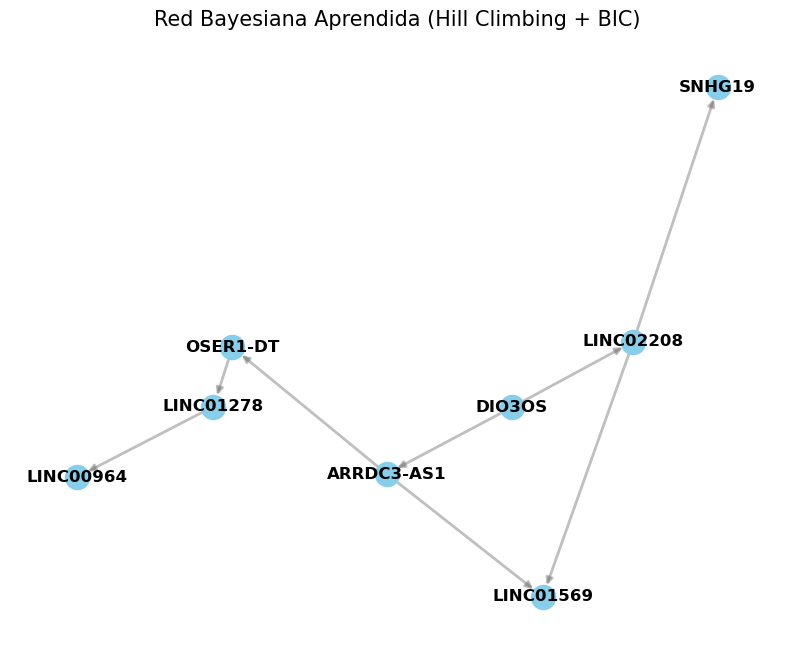

In [ ]:
hc = HillClimbSearch(data_encoded)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.spring_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana Aprendida (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

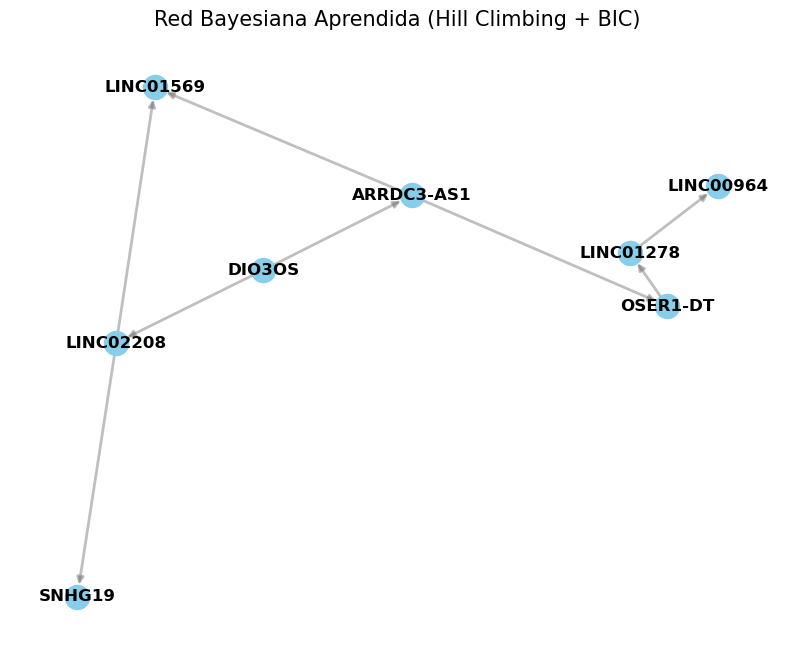

In [ ]:
labels = ['bajo', 'alto']
df_discretized = df_final.copy()
for col in df_final.columns:
    df_discretized[col] = pd.qcut(df_final[col], q=2, labels=labels, duplicates='drop')

data_encoded = pd.DataFrame()

for col in df_discretized.columns:
    dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
    dummies = dummies.drop(columns=[col + '_alto'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
    data_encoded = pd.concat([data_encoded, dummies], axis=1)
data_encoded = data_encoded.astype(int)
data_encoded.columns = data_encoded.columns.str.replace('_bajo', '', regex=False)

hc = HillClimbSearch(data_encoded)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.spring_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana Aprendida (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

# Borrador

In [ ]:
# Separar variables y target
X = df2.drop(columns='Grupo_Tratamiento')
X = X[coef_df['Variable'].to_list()]  # Seleccionar solo las variables del dataframe de coeficientes
y = df2['Grupo_Tratamiento']

# Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Estándariza X sin la constante

X_scaled = pd.DataFrame(X_scaled, columns=X.columns,index = y.index)


# Ajustar el modelo de regresión logística
model = sm.Logit(y, X_scaled)
result = model.fit()

# Mostrar un resumen con p-valores, coeficientes y pseudo R^2
print(result.summary())

# Obtener el pseudo R^2 de McFadden
pseudo_r2 = 1 - (result.llf / result.llnull)
print(f"Pseudo R^2: {pseudo_r2}")

In [ ]:
# Inicializar lista para guardar los resultados
resultados = []

# Número de iteraciones del bootstrap
n_iter = 10000
random_state = 42  # puedes quitar esto si quieres total aleatoriedad

np.random.seed(random_state)

X_total = df2.drop(columns='Grupo_Tratamiento')
y_total = df2['Grupo_Tratamiento']
variables_totales = X_total.columns.tolist()

for i in tqdm(range(n_iter)):
    # Selección aleatoria de variables
    n_vars = np.random.randint(5, len(variables_totales) + 1)
    vars_seleccionadas = np.random.choice(variables_totales, size=n_vars, replace=False)

    # Subset de datos
    X = X_total[vars_seleccionadas]
    y = y_total

    # Hacer bootstrap del conjunto de entrenamiento (con reemplazo)
    X_boot, y_boot = resample(X, y, replace=True, n_samples=len(X), random_state=None)

    # Out-of-bag samples (muestras que no están en el bootstrap)
    mask = ~X.index.isin(X_boot.index)
    X_oob = X.loc[mask]
    y_oob = y.loc[mask]

    # Escalar
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_oob_scaled = scaler.transform(X_oob) if not X_oob.empty else None

    # Hiperparámetro aleatorio
    c_value = 10 ** np.random.uniform(-2, 2)

    # Entrenar
    modelo = LogisticRegression(penalty='l1', solver='liblinear', C=c_value, max_iter=1000)
    modelo.fit(X_boot_scaled, y_boot)

    # Evaluar (solo si hay muestras OOB)
    if X_oob_scaled is not None and len(y_oob) > 0:
        y_pred_oob = modelo.predict(X_oob_scaled)
        y_pred_boot = modelo.predict(X_boot_scaled)
        r2 = r2_score(y_oob, y_pred_oob)
        acc_oob = accuracy_score(y_oob, y_pred_oob)
        acc_boot = accuracy_score(y_boot, y_pred_boot)
    else:
        r2 = np.nan
        acc_oob = np.nan
        acc_boot = accuracy_score(y_boot, modelo.predict(X_boot_scaled))

    # Guardar resultados
    for var, coef in zip(vars_seleccionadas, modelo.coef_[0]):
        resultados.append({
            'Iteración': i,
            'Variable': var,
            'Coeficiente': coef,
            'C': c_value,
            'R2': r2,
            'Accuracy_Test': acc_oob,
            'Accuracy_Train': acc_boot
        })

df_resultados = pd.DataFrame(resultados)

#df_resultados = df_resultados[df_resultados['Coeficiente'] != 0]
df_resultados_bootstrpaLogit = df_resultados.groupby('Variable').agg(
    Conteo=('Variable', 'count'),
    Promedio_Coeficiente=('Coeficiente', 'mean'),
    Promedio_Train_accuracy=('Accuracy_Train','mean'),
    Promedio_Test_accuracy=('Accuracy_Test','mean')
).reset_index()



# Ordenar por porcentaje y promedio de importancia

df_resultados_bootstrpaLogit['Importancia (abs)'] = np.abs(df_resultados_bootstrpaLogit['Promedio_Coeficiente'])
df_resultados_bootstrpaLogit = df_resultados_bootstrpaLogit.sort_values(by=['Importancia (abs)'], ascending=False).drop(columns='Importancia (abs)')
df_resultados_bootstrpaLogit

In [ ]:
#####CLUSTERING PARA SABER SI INDIVIDUOS DE CONTROL O TRATAMIENTO SE INCLUYEN EN UN MISMO CLUSTER

# Método del Codo
df_scaled1 = df_scaled.copy()
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Evaluamos entre 2 y 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_scaled1)
    
    # Guardamos la inercia para la técnica del codo
    inertia.append(kmeans.inertia_)
    
    # Calculamos el score de silueta para el método de silueta
    score = silhouette_score(df_scaled1, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfico del Método del Codo
plt.figure(figsize=(14, 6))

# Subgráfico para la técnica del codo
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True)

# Subgráfico para el Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

ncluster = 2
kmeans = KMeans(n_clusters=ncluster, random_state=42) #2 clusters, uno de control y otro de tratamiento
kmeans.fit(df_scaled1)
# Asignar cada variable a un cluster
clusters = kmeans.labels_
df_scaled1['cluster'] = clusters

for cluster in range(ncluster):
    df_scaled1Clust = df_scaled1[df_scaled1['cluster'] == cluster].reset_index()
    df_scaled1Clust['Grupo'] = np.where(df_scaled1Clust['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled1Clust['index'].str.contains('C'), 'Control', 'Otro'))
    conteo = df_scaled1Clust['Grupo'].value_counts()
    proporcion = df_scaled1Clust['Grupo'].value_counts(normalize=True) * 100
    print('CLUSTER',cluster)
    for categoria, (cantidad, prop) in zip(conteo.index, zip(conteo, proporcion)):
            print(f"{categoria}: {cantidad} ({prop:.2f}%)")

In [ ]:
############################################ OLS ############################
import statsmodels.api as sm

X = df_scaled2.drop(columns=["Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 5 variables aleatorias y hacer la regresión
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 5 variables
    selected_features = random.sample(list(X.columns), 5)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    # Ajustar el modelo de regresión lineal
    model = sm.OLS(y, X_selected_with_intercept)
    result = model.fit()
    
    for feature in selected_features:
        coefficients_dict[feature].append((float(result.params[feature])))
        p_values_dict[feature].append((float(result.pvalues[feature])))
        


mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

results_df = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

results_df = results_df[results_df['P-Valor Promedio']<0.05]
mostImpFeaturesRegression = results_df.sort_values('Coeficiente Promedio', ascending = False)
mostImpFeaturesRegression

In [ ]:
########################################### LOGÍSTICA ###################################33
import warnings
warnings.filterwarnings("ignore")

X = df_scaled2.drop(columns=["cluster", "Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 3 variables aleatorias y hacer la regresión logística
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 3 variables
    selected_features = random.sample(list(X.columns), 1)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    try:
        model = sm.Logit(y, X_selected_with_intercept)
        result = model.fit(disp=0)  # Evita que se muestre el resultado durante el ajuste
        
        for feature in selected_features:
            coefficients_dict[feature].append(float(result.params[feature]))
            p_values_dict[feature].append(float(result.pvalues[feature]))
    except:
        # Si ocurre un error (como singularidad), simplemente continuar con la siguiente iteración
        continue
# Calcular las medias de los coeficientes y p-valores
mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

# Crear DataFrame con los resultados
results_df_log = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

# Filtrar para obtener solo aquellas variables con p-valor menor que 0.05
#results_df = results_df[results_df['P-Valor Promedio'] < 0.05]

results_df_log_MasSignificativos = results_df_log[results_df_log['P-Valor Promedio'] < 0.05].sort_values('Coeficiente Promedio',ascending = False)
#results_df_log_MasSignificativos['CoeficienteInterpretacion'] = np.exp(results_df_log_MasSignificativos['Coeficiente Promedio'])
results_df_log_MasSignificativos = results_df_log_MasSignificativos
results_df_log_MasSignificativos

In [ ]:
########### COMPARACIÓN DE RESULTADOS


treelist = mostImpFeaturesTree['Feature'].to_list()
reglist = mostImpFeaturesRegression['Variable'].to_list()
loglists = results_df_log_MasSignificativos['Variable'].to_list()

all_items = set(treelist + reglist + loglists)
df_comparacion = pd.DataFrame({'variable': list(all_items)})
df_comparacion['Arbol'] = df_comparacion['variable'].isin(treelist).astype(int)
df_comparacion['OLS'] = df_comparacion['variable'].isin(reglist).astype(int)
df_comparacion['Logistic'] = df_comparacion['variable'].isin(loglists).astype(int)

df_comparacion['frecuencia_total'] = (
    df_comparacion['Arbol'] +
    df_comparacion['OLS'] +
    df_comparacion['Logistic']
)
df_comparacion = df_comparacion.sort_values(by='frecuencia_total', ascending=False)
df_comparacion[df_comparacion['frecuencia_total'] >= 2]